<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula06a_mnist_flat_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


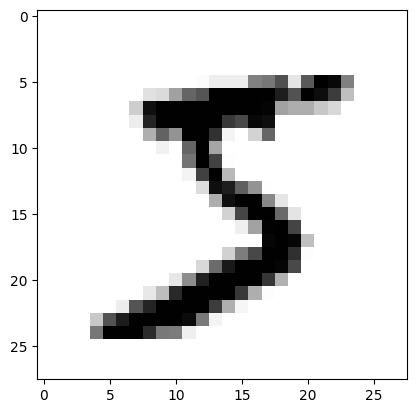

In [3]:
from matplotlib import pyplot as plt
digit = train_images[0]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [5]:
train_labels[0]

np.uint8(5)

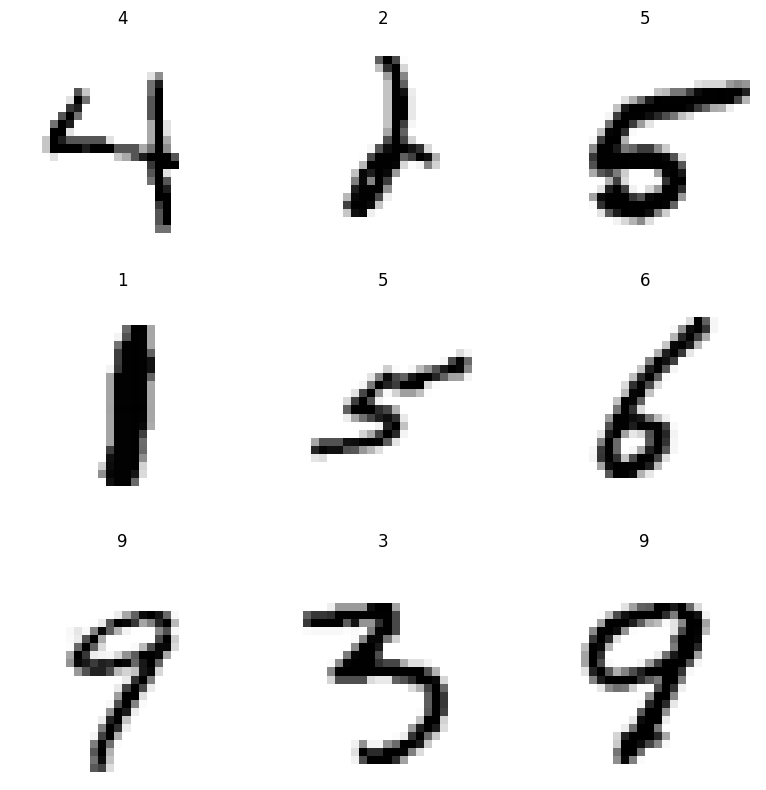

In [9]:
import numpy as np
samples = np.random.randint(0, train_images.shape[0], 9)
plt.figure(figsize=(8, 8))
for i, sample in enumerate(samples):
    plt.subplot(3, 3, i+1)
    digit = train_images[sample]
    plt.imshow(digit, cmap=plt.cm.binary)
    plt.title(train_labels[sample])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
train_flat_images = train_images.reshape((60000, 28*28))
test_flat_images = test_images.reshape((10000, 28*28))
print(train_flat_images.shape)
print(test_flat_images.shape)

(60000, 784)
(10000, 784)


In [11]:
print(f"n_classes: {len(np.unique(train_labels))}")

n_classes: 10


In [12]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    train_flat_images,
    train_labels,
    epochs=5,
    batch_size=128
)

test_loss, test_acc = model.evaluate(test_flat_images, test_labels)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8982 - loss: 6.1150 
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9539 - loss: 0.7360
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9659 - loss: 0.4855
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9726 - loss: 0.3796
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9765 - loss: 0.3200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9670 - loss: 0.6279
Test accuracy: 0.9670000076293945
Test loss: 0.6279158592224121


In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np

def BasicKerasNN(num_classes):
  return keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
  ])

class KerasWrappedNN(BaseEstimator, ClassifierMixin):
  def __init__(self, epochs=5, batch_size=128, model_fabric=BasicKerasNN):
    self.epochs = epochs
    self.batch_size = batch_size
    self.model_fabric = model_fabric

  def fit(self, X, y):
    self.labels, ids = np.unique(y, return_inverse=True)
    y_hot = keras.utils.to_categorical(ids, len(self.labels))
    self.model = self.model_fabric(num_classes=len(np.unique(y)))
    self.model.compile(
        optimizer="rmsprop",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    self.model.fit(
        X, y_hot,
        epochs=self.epochs,
        batch_size=self.batch_size
    )
    return self

  def predict(self, X):
    y_pred = self.model.predict(X)
    return self.labels[np.argmax(y_pred, axis=1)]

model = KerasWrappedNN(epochs=5, batch_size=128, model_fabric=BasicKerasNN)
model.fit(train_flat_images, train_labels)
y_pred = model.predict(test_flat_images)
accuracy_score(test_labels, y_pred)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8969 - loss: 5.7601
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9531 - loss: 0.6811
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9648 - loss: 0.4568
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9721 - loss: 0.3429
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9761 - loss: 0.2823
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.9649

In [14]:
print(train_flat_images[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0   0   0   0   

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model)
])

pipeline.fit(train_flat_images, train_labels)
y_pred = pipeline.predict(test_flat_images)
accuracy_score(test_labels, y_pred)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9398 - loss: 0.2149
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9752 - loss: 0.0843
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9848 - loss: 0.0498
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9905 - loss: 0.0318
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9941 - loss: 0.0200
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.9759

In [17]:
from sklearn.base import TransformerMixin

class Divide255(TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    return X / 255.0

pipeline = Pipeline([
    ("scaler", Divide255()),
    ("model", model)
])

pipeline.fit(train_flat_images, train_labels)
y_pred = pipeline.predict(test_flat_images)
accuracy_score(test_labels, y_pred)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9252 - loss: 0.2620
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9685 - loss: 0.1063
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9790 - loss: 0.0703
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9852 - loss: 0.0506
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9886 - loss: 0.0378
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.9826

In [20]:
class Flatten(TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    return X.reshape((X.shape[0], -1))

pipeline = Pipeline([
    ("flatten", Flatten()),
    ("scaler", Divide255()),
    ("model", model)
])

pipeline.fit(train_images, train_labels)
y_pred = pipeline.predict(test_images)
accuracy_score(test_labels, y_pred)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9248 - loss: 0.2637
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9671 - loss: 0.1091
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9788 - loss: 0.0705
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9839 - loss: 0.0521
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9882 - loss: 0.0389
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.9813

In [21]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("flatten", Flatten()),
    ("scaler", Divide255()),
    ("model", RandomForestClassifier(n_estimators=100))
])

pipeline.fit(train_images, train_labels)
y_pred = pipeline.predict(test_images)
accuracy_score(test_labels, y_pred)

0.9695